<a href="https://www.kaggle.com/code/jobayer360s/ai-and-ds-job-salary-pred-by-data-mininnig?scriptVersionId=342205493" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Importing Necessary Libaries

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import pandas as pd
import numpy as np
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


# Load Data set

Loding the dataset before EDA and for data understanding

In [2]:
import kagglehub
path = kagglehub.dataset_download("uditjain13/ai-and-data-science-job-salaries-2026")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/uditjain13/ai-and-data-science-job-salaries-2026


In [3]:
df = pd.read_csv("/kaggle/input/datasets/uditjain13/ai-and-data-science-job-salaries-2026/ai_ds_job_salaries_2026.csv")
df.head(5)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,...,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,...,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1


In [4]:
df.tail(5)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
4995,Data Analyst,Mid,Full-time,M,PL,PL,Finance,50,9.3,Masters,...,1.5,PLN,38810,0.182,12.0,7.3,2,False,7.8,4.8
4996,Machine Learning Engineer,Lead,Full-time,M,ES,ES,Technology,0,13.3,Self-taught,...,2.6,EUR,123368,0.000,11.0,5.5,7,False,4.0,1.3
4997,Data Science Manager,Senior,Full-time,M,PL,PL,Technology,50,8.1,Bachelors,...,9.7,PLN,86123,0.078,13.3,7.0,6,True,19.2,2.7
4998,Research Scientist,Senior,Freelance,M,PL,PL,Technology,0,12.9,Bachelors,...,10.7,PLN,76001,0.122,10.1,6.0,4,True,10.8,1.5
4999,Business Intelligence Analyst,Entry,Contract,M,US,US,Government,0,2.1,Masters,...,10.4,USD,49321,0.022,4.8,6.6,3,False,6.9,6.1


# Perform EDA . 
To Understand data  we have performing EDA exploratory data analysis EDA

In [5]:
print('DataFrame Info:')
df.info()

print('\nMissing values per column:')
print(df.isnull().sum())

print('\nDescriptive statistics:')
df.describe().T

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   object 
 1   experience_level            5000 non-null   object 
 2   employment_type             5000 non-null   object 
 3   company_size                5000 non-null   object 
 4   company_location            5000 non-null   object 
 5   employee_residence          5000 non-null   object 
 6   industry                    5000 non-null   object 
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   object 
 10  primary_language            5000 non-null   object 
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size        

,count,mean,std,min,25%,50%,75%,max
remote_ratio,5000.0,43.08000,41.454280,0.0,0.000,50.000,100.000,100.000
years_experience,5000.0,8.36144,4.820808,0.0,4.800,8.100,11.500,23.700
team_size,5000.0,7.93620,2.647930,1.0,6.000,8.000,10.000,19.000
certifications_count,5000.0,1.82040,1.344212,0.0,1.000,2.000,3.000,8.000
weekly_hours,5000.0,44.34540,6.142761,24.4,40.100,44.400,48.500,67.300
ai_tools_hours_per_week,5000.0,8.43740,5.503637,0.0,3.300,8.500,12.625,25.200
salary_usd,5000.0,98605.40620,55369.310473,12000.0,55592.750,90572.000,129657.750,372347.000
equity_offered_pct,5000.0,0.13902,0.184243,0.0,0.017,0.072,0.175,1.264
bonus_pct,5000.0,10.80272,5.152959,0.0,7.100,10.600,14.200,30.800
job_satisfaction_score,5000.0,6.68532,1.364302,1.1,5.800,6.700,7.600,10.000


In [6]:
df.columns

Index(['job_title', 'experience_level', 'employment_type', 'company_size',
       'company_location', 'employee_residence', 'industry', 'remote_ratio',
       'years_experience', 'education_level', 'primary_language',
       'has_ml_in_title', 'manages_people', 'team_size',
       'certifications_count', 'weekly_hours', 'uses_ai_tools_daily',
       'ai_tools_hours_per_week', 'salary_currency', 'salary_usd',
       'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score',
       'interviews_to_offer', 'switched_jobs_last_year',
       'upskilling_hours_per_month', 'fears_ai_automation_score'],
      dtype='object')

In [7]:
df.isnull().sum()

job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64

In [8]:
print("Dataset shape ",df.shape)
print("Duplicate ",df.duplicated().sum())

Dataset shape  (5000, 27)
Duplicate  0


In [9]:
print("Job Titles:", df['job_title'].nunique())
print(df['job_title'].value_counts())

Job Titles: 12
job_title
Data Scientist                   709
Data Engineer                    682
Data Analyst                     627
Machine Learning Engineer        593
AI Engineer                      506
Analytics Engineer               317
MLOps Engineer                   306
Business Intelligence Analyst    293
Research Scientist               269
LLM Engineer                     242
Data Science Manager             238
Computer Vision Engineer         218
Name: count, dtype: int64


# Salary Distribution


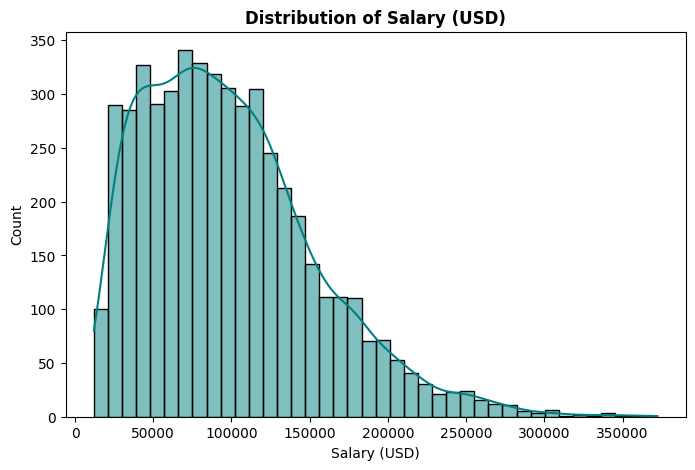

count      5000.000000
mean      98605.406200
std       55369.310473
min       12000.000000
25%       55592.750000
50%       90572.000000
75%      129657.750000
max      372347.000000
Name: salary_usd, dtype: float64


In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary_usd'], bins=40, kde=True, color='teal')
plt.title("Distribution of Salary (USD)",fontweight='bold')
plt.xlabel("Salary (USD)")
plt.show()

print(df['salary_usd'].describe())

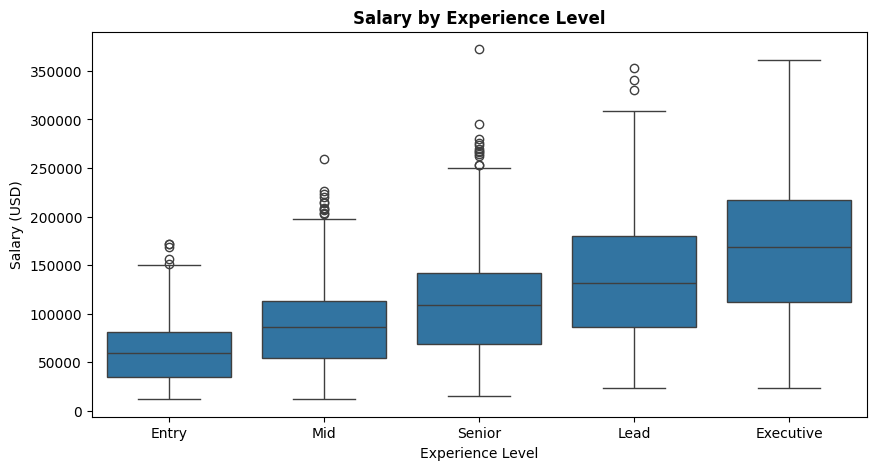

In [11]:
plt.figure(figsize=(10,5))
order = df.groupby('experience_level')['salary_usd'].median().sort_values().index
sns.boxplot(data=df, x='experience_level', y='salary_usd', order=order)
plt.title("Salary by Experience Level",fontweight='bold')
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.show()

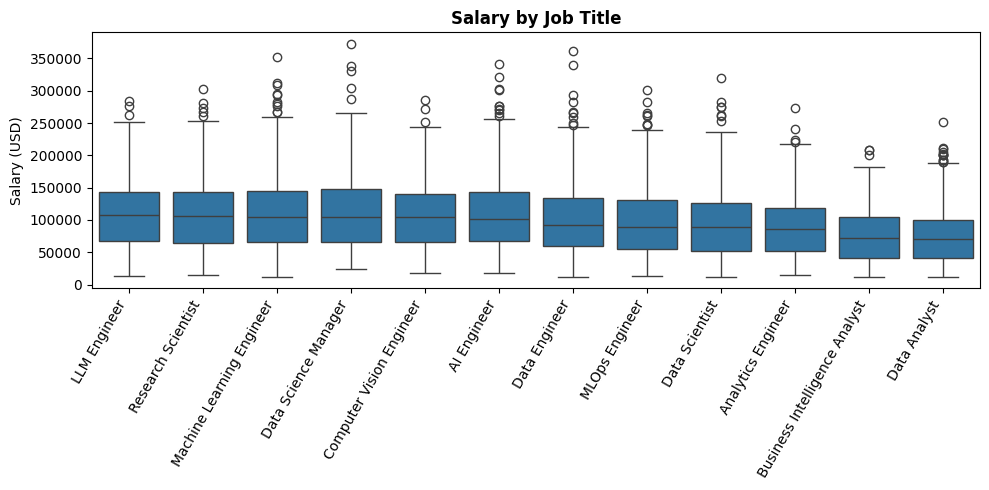

In [12]:
plt.figure(figsize=(10,5))
order = df.groupby('job_title')['salary_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='job_title', y='salary_usd', order=order)
plt.title("Salary by Job Title",fontweight='bold')
plt.xticks(rotation=60, ha='right')
plt.xlabel("")
plt.ylabel("Salary (USD)")
plt.tight_layout()
plt.show()

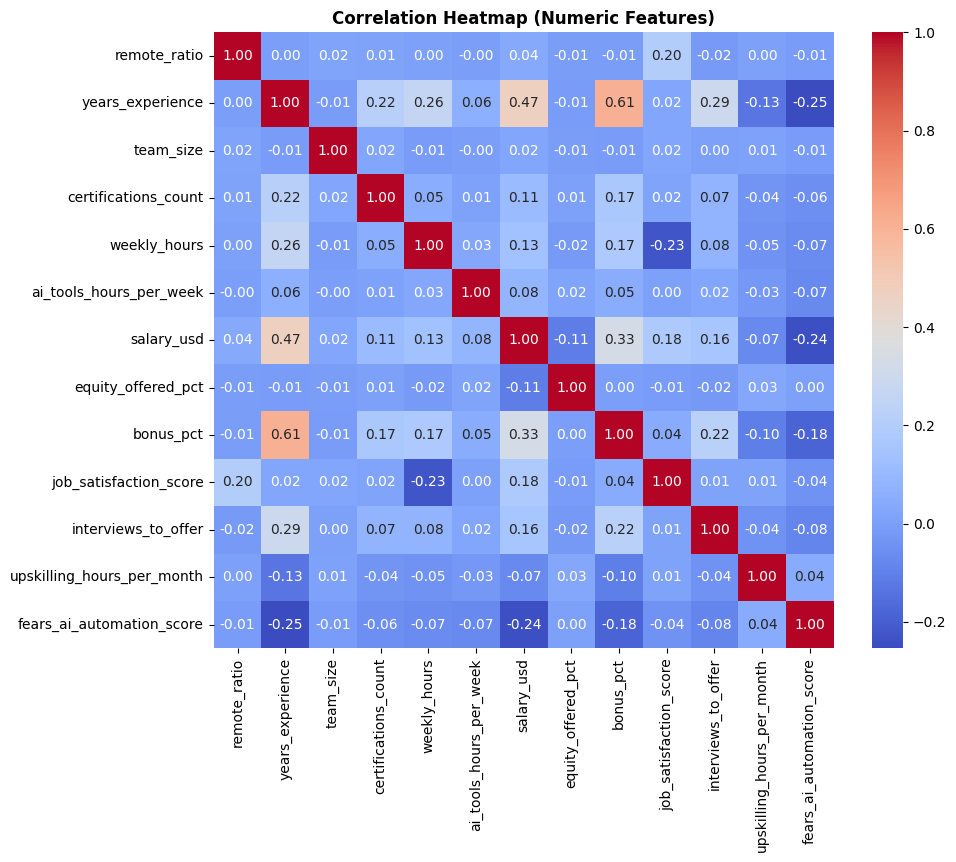

In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap (Numeric Features)",fontweight='bold')
plt.show()

# Preprocessing & Train-Test Split
We separate the target (salary_usd) from the features, identify categorical vs numeric columns, and one-hot encode the categorical ones. We hold out 20% of the data as a test set that the model never sees during training — this is how we get an honest estimate of performance.

In [14]:


target = 'salary_usd'
X = df.drop(columns=[target])
y = df[target]

cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("\nTrain size:", X_train.shape, " Test size:", X_test.shape)

Categorical columns: ['job_title', 'experience_level', 'employment_type', 'company_size', 'company_location', 'employee_residence', 'industry', 'education_level', 'primary_language', 'has_ml_in_title', 'manages_people', 'uses_ai_tools_daily', 'salary_currency', 'switched_jobs_last_year']
Numeric columns: ['remote_ratio', 'years_experience', 'team_size', 'certifications_count', 'weekly_hours', 'ai_tools_hours_per_week', 'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score', 'interviews_to_offer', 'upskilling_hours_per_month', 'fears_ai_automation_score']

Train size: (4000, 26)  Test size: (1000, 26)


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'   # keep numeric columns as-is
)

# Model Building

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=400, learning_rate=0.05, random_state=42, verbose=-1)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    results.append({'Model': name, 'R2 Score': round(r2, 4), 'MAE': round(mae, 1), 'RMSE': round(rmse, 1)})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,R2 Score,MAE,RMSE
0,LightGBM,0.8416,15181.1,21952.1
1,XGBoost,0.8372,15598.0,22258.6
2,Linear Regression,0.8062,18114.1,24282.2
3,Random Forest,0.7690,18692.4,26508.5


# Model Comparision

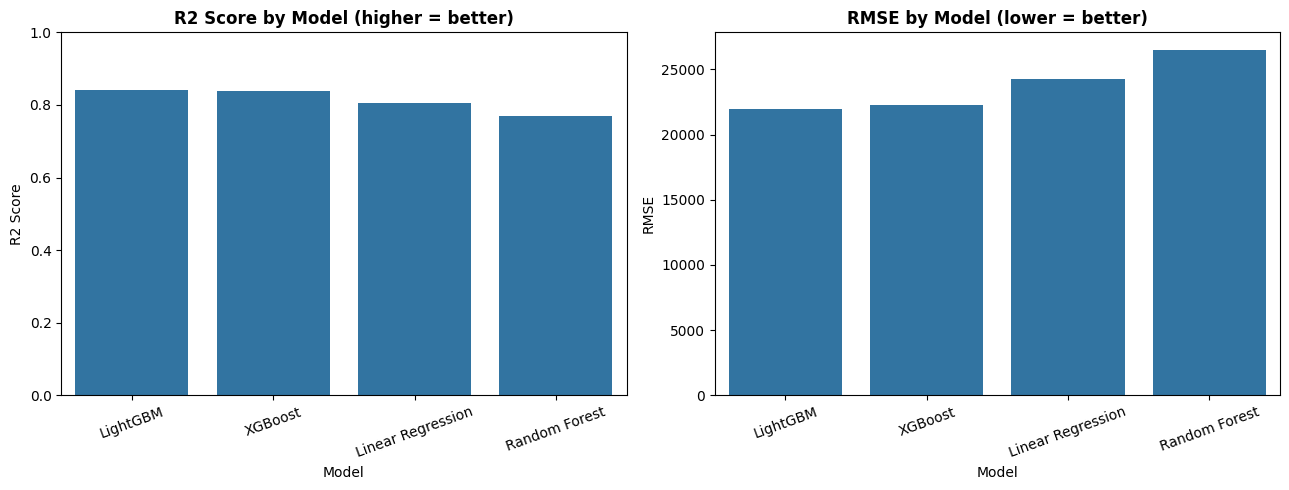

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.barplot(data=results_df, x='Model', y='R2 Score', ax=axes[0])
axes[0].set_title("R2 Score by Model (higher = better)",fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[1])
axes[1].set_title("RMSE by Model (lower = better)",fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

#  Feature Importance (Best Model)
Which features drive the model's salary predictions the most?

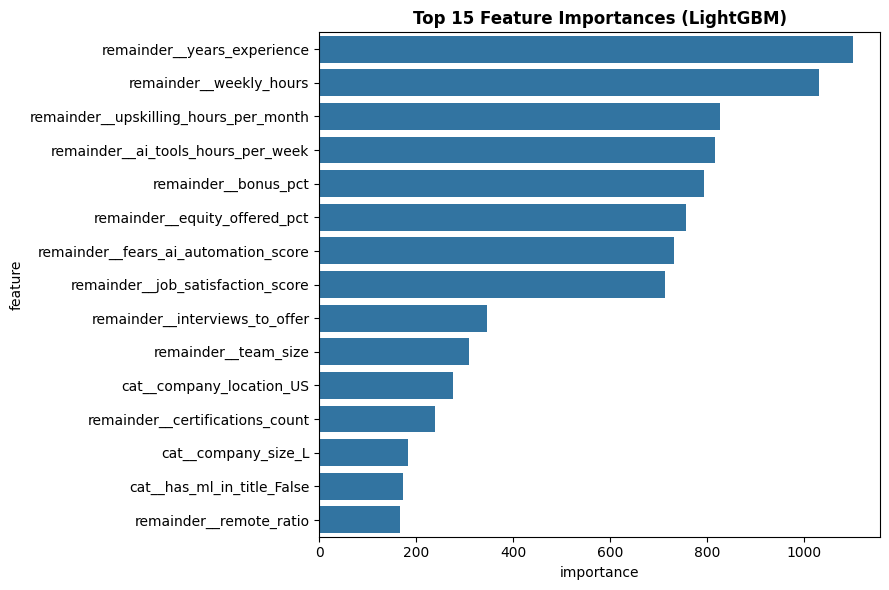

In [18]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = fitted_pipelines[best_model_name]

feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = best_pipe.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9,6))
sns.barplot(data=fi_df, x='importance', y='feature')
plt.title(f"Top 15 Feature Importances ({best_model_name})",fontweight='bold')
plt.tight_layout()
plt.show()